In [1]:
import warnings
warnings.filterwarnings("ignore")
from mlflow import MlflowClient, set_tracking_uri
import mlflow
from typing import Tuple
from tqdm import tqdm
import pandas as pd
from datetime import datetime, timedelta
import mysql.connector
import pyarrow
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import argparse
import os
from dateutil.relativedelta import relativedelta
import json
from typing import Dict, Any

from functions_daily import get_cutoff_indices, transform_ts_data_into_features_and_target, train_test_split, ts_into_features_Daily, get_daily_data
from ft_tables import load_data
from functions import charge_model
from train_tsif_model_daily import mlflow_daily, mlflow_daily_register


In [6]:
def predict_exchange_future(exchange, model_name, days: int):

    df_original = get_daily_data(exchange)

    df = df_original[['id_date', 'Open', 'Exchange']]
    df['datetime'] = pd.to_datetime(df['id_date'], format='%Y%m%d')
    df = df[['datetime', 'Open', 'Exchange']]

    features, targets = transform_ts_data_into_features_and_target(
        df,
        input_seq_len=31,  # one week of history -> 24*7*1
        step_size=1,
    )

    past_close_columns = [c for c in features.columns if c.startswith('open_')]

    features_only_numeric = features[past_close_columns]
    dates = features[['datetime']]

    df_result = pd.DataFrame()
    df_dates = pd.DataFrame()

    last_day = features_only_numeric.iloc[-1:]
    last_date = dates.iloc[-1:]

    model = charge_model(exchange, model_name)
    if model is None:
        print("There is no model")

    prediction = model.predict(last_day)

    df_result = pd.concat([df_result, last_day], ignore_index=True)
    df_result['predicted_price'] = prediction

    # Dates
    last_date_day = last_date.iloc[-1]
    df_dates = pd.concat([df_dates, last_date], ignore_index=True)
    day = last_date_day

    for i in range(1, days):
        last_row = df_result.iloc[-1]
        last_row = last_row.drop('predicted_price')

        new_row = last_row.shift(-1)
        new_row['open_previous_1_day'] = prediction
        new_row_df = pd.DataFrame([new_row], columns=df_result.columns)

        prediction = model.predict(new_row_df)
        new_row_df['predicted_price'] = prediction

        df_result = pd.concat([df_result, new_row_df], ignore_index=True)

        # Dates
        day = day + timedelta(days=1)
        new_row_date = pd.DataFrame([day], columns=df_dates.columns)
        df_dates = pd.concat([df_dates, new_row_date], ignore_index=True)

    result = pd.concat([df_result, df_dates], axis=1)
    result['exchange'] = exchange
    
    result = result[['datetime', 'exchange', 'predicted_price']]
    result['datetime'] = result['datetime'].dt.strftime('%Y-%m-%dT%H:%M:%S')
    

    # Convert the result DataFrame to JSON
    result = result.to_dict(orient='records')  # Convert DataFrame to a list of dictionaries
    return result

In [7]:
exchange = 'BTC-USD'
model = 'LinearRegression'
days = 30

print(type(days))

result = predict_exchange_future(exchange, model, days)

<class 'int'>
MySQL DB Connected


100%|██████████| 1/1 [00:01<00:00,  1.44s/it]


Model loaded successfully.


In [8]:
result

[{'datetime': '2024-08-16T00:00:00',
  'exchange': 'BTC-USD',
  'predicted_price': 58843.9140625},
 {'datetime': '2024-08-17T00:00:00',
  'exchange': 'BTC-USD',
  'predicted_price': 58547.5},
 {'datetime': '2024-08-18T00:00:00',
  'exchange': 'BTC-USD',
  'predicted_price': 59008.0078125},
 {'datetime': '2024-08-19T00:00:00',
  'exchange': 'BTC-USD',
  'predicted_price': 58879.734375},
 {'datetime': '2024-08-20T00:00:00',
  'exchange': 'BTC-USD',
  'predicted_price': 59005.0234375},
 {'datetime': '2024-08-21T00:00:00',
  'exchange': 'BTC-USD',
  'predicted_price': 58706.4453125},
 {'datetime': '2024-08-22T00:00:00',
  'exchange': 'BTC-USD',
  'predicted_price': 59009.1953125},
 {'datetime': '2024-08-23T00:00:00',
  'exchange': 'BTC-USD',
  'predicted_price': 59444.7421875},
 {'datetime': '2024-08-24T00:00:00',
  'exchange': 'BTC-USD',
  'predicted_price': 59468.8671875},
 {'datetime': '2024-08-25T00:00:00',
  'exchange': 'BTC-USD',
  'predicted_price': 59149.453125},
 {'datetime': '202

In [2]:
def predict_test_data(exchange):
    
    model = None

    # IS THERE ANY MODEL? 
    try:
        model = charge_model(exchange)
    
    
    except Exception as e:
        print(f"{e}")
        return None
    
    # NO MODEL
    if model is None:
        
        print("There is no model")
        
        df_original = get_daily_data(exchange)
        #print(df_original)
        
        # NO DATA
        #if df_original == None:
        if len(df_original) < 1:
            
            #Load the data:
            load_data(exchange)
            print("Data loaded")
            
            #Train and register the model:
            mlflow_daily_register(exchange)
            
            #Charge the model:
            model = charge_model(exchange)
            
            #Get the data to predict:
            X_test_only_numeric, X_train_only_numeric, y_test, y_train, X_train, X_test = ts_into_features_Daily(exchange)
            
            #Predict
            predictions = model.predict(pd.DataFrame(X_test_only_numeric))
            return predictions 
        
        # DATA 
        else:
            #Train and register the model:
            mlflow_daily_register(exchange)
            
            #Charge the model:
            model = charge_model(exchange)
            
            #Get the data to predict:
            X_test_only_numeric, X_train_only_numeric, y_test, y_train, X_train, X_test = ts_into_features_Daily(exchange)
            
            #Predict
            predictions = model.predict(pd.DataFrame(X_test_only_numeric))
            return predictions 
            
    # MODEL       
    else:
        
        print("There is a model registered")
        
        df_original = get_daily_data(exchange)
        
        # NO DATA
        if len(df_original) < 1:
            
            # Load the data:
            load_data(exchange)
            print("Data loaded")
            
            # Get data
            X_test_only_numeric, X_train_only_numeric, y_test, y_train, X_train, X_test = ts_into_features_Daily(exchange)
            
            # Predict
            predictions = model.predict(pd.DataFrame(X_test_only_numeric))
            return predictions 
            
            
        # DATA
        else:
            
            # Get data
            X_test_only_numeric, X_train_only_numeric, y_test, y_train, X_train, X_test = ts_into_features_Daily(exchange)
            
            # Predict
            predictions = model.predict(pd.DataFrame(X_test_only_numeric))
            return predictions


In [19]:
exchange = '^GSPC'

predictions = predict_test_data(exchange)

predictions

Error loading model: RESOURCE_DOES_NOT_EXIST: Registered Model with name=^GSPC_Daily_Model not found
There is no model
MySQL DB Connected
MySQL DB Connected
MySQL DB Connected


100%|██████████| 1/1 [00:02<00:00,  2.40s/it]
2024/07/24 18:12:18 WARNING mlflow.models.model: Logging model metadata to the tracking server has failed. The model artifacts have been logged successfully under mlflow-artifacts:/454064318007568469/be36e9c8e5be4ae6ba4200129beb32df/artifacts. Set logging level to DEBUG via `logging.getLogger("mlflow").setLevel(logging.DEBUG)` to see the full traceback.
Successfully registered model '^GSPC_Daily_Model'.
2024/07/24 18:12:18 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: ^GSPC_Daily_Model, version 1
Created version '1' of model '^GSPC_Daily_Model'.


Model loaded successfully.
MySQL DB Connected


100%|██████████| 1/1 [00:01<00:00,  1.87s/it]


array([5009.9976, 5083.3525, 5100.503 , 5097.9375, 5143.9526, 5119.3477,
       5139.116 , 5151.3003, 5155.7935, 5111.318 , 5165.658 , 5154.784 ,
       5167.527 , 5181.379 , 5204.068 , 5230.382 , 5189.145 , 5225.232 ,
       5223.527 , 5202.721 , 5221.6084, 5175.9106, 5196.9395, 5196.119 ,
       5179.073 , 5187.806 , 5153.956 , 5170.7827, 5163.4365, 5160.51  ,
       5146.692 , 5149.6187, 5151.537 , 5151.537 , 5151.537 , 5151.537 ,
       5151.537 , 5151.537 , 5151.537 , 5151.537 , 5151.537 , 5151.537 ,
       5151.537 , 5151.537 , 5151.537 , 5151.537 , 5151.537 , 5151.537 ,
       5151.537 , 5151.537 , 5151.537 , 5151.537 , 5151.537 , 5151.537 ,
       5151.537 ], dtype=float32)

In [3]:
def return_test_prediction_data(exchange):
        
        X_test_only_numeric, X_train_only_numeric, y_test, y_train, X_train, X_test = ts_into_features_Daily(exchange)
        predictions = predict_test_data(exchange)

        #historical_data = 

        X_train = X_train[['datetime']]
        X_train['Open'] = y_train
        X_train['Exchange'] = exchange
        X_train

        X_test = X_test[['datetime']]
        X_test['Open'] = y_test
        X_test['Exchange'] = exchange
        X_test

        pred = X_test[['datetime']]
        pred['Open'] = predictions
        pred['Exchange'] = exchange


        train_test = pd.concat([X_train, X_test], ignore_index = True)
        
        return train_test, pred

In [4]:
def return_test_prediction_data(exchange):
    X_test_only_numeric, X_train_only_numeric, y_test, y_train, X_train, X_test = ts_into_features_Daily(exchange)
    predictions = predict_test_data(exchange)

    X_train = X_train[['datetime']]
    X_train['Open'] = y_train
    X_train['Exchange'] = exchange

    X_test = X_test[['datetime']]
    X_test['Open'] = y_test
    X_test['Exchange'] = exchange

    pred = X_test[['datetime']]
    pred['Open'] = predictions
    pred['Exchange'] = exchange

    train_test = pd.concat([X_train, X_test], ignore_index=True)

    train_test_json = train_test.to_json(orient="records")
    pred_json = pred.to_json(orient="records")

    result = {
        "train_test": json.loads(train_test_json),
        "pred": json.loads(pred_json)
    }

    return result

In [8]:
exchange = 'BTC-USD'
#train , predictions = return_test_prediction_data(exchange)
results = return_test_prediction_data(exchange)
results

MySQL DB Connected


100%|██████████| 1/1 [00:02<00:00,  2.93s/it]


Model loaded successfully.
There is a model registered
MySQL DB Connected
MySQL DB Connected


100%|██████████| 1/1 [00:02<00:00,  2.46s/it]


{'train_test': [{'datetime': 1413590400000,
   'Open': 384.0,
   'Exchange': 'BTC-USD'},
  {'datetime': 1413676800000, 'Open': 391.0, 'Exchange': 'BTC-USD'},
  {'datetime': 1413763200000, 'Open': 389.0, 'Exchange': 'BTC-USD'},
  {'datetime': 1413849600000, 'Open': 382.0, 'Exchange': 'BTC-USD'},
  {'datetime': 1413936000000, 'Open': 386.0, 'Exchange': 'BTC-USD'},
  {'datetime': 1414022400000, 'Open': 383.0, 'Exchange': 'BTC-USD'},
  {'datetime': 1414108800000, 'Open': 359.0, 'Exchange': 'BTC-USD'},
  {'datetime': 1414195200000, 'Open': 359.0, 'Exchange': 'BTC-USD'},
  {'datetime': 1414281600000, 'Open': 347.0, 'Exchange': 'BTC-USD'},
  {'datetime': 1414368000000, 'Open': 355.0, 'Exchange': 'BTC-USD'},
  {'datetime': 1414454400000, 'Open': 353.0, 'Exchange': 'BTC-USD'},
  {'datetime': 1414540800000, 'Open': 357.0, 'Exchange': 'BTC-USD'},
  {'datetime': 1414627200000, 'Open': 336.0, 'Exchange': 'BTC-USD'},
  {'datetime': 1414713600000, 'Open': 345.0, 'Exchange': 'BTC-USD'},
  {'datetime':

In [7]:
train

'train_test'

MySQL DB Connected


100%|██████████| 1/1 [00:01<00:00,  1.80s/it]


Model loaded successfully.
There is a model registered
MySQL DB Connected
MySQL DB Connected


100%|██████████| 1/1 [00:01<00:00,  1.85s/it]


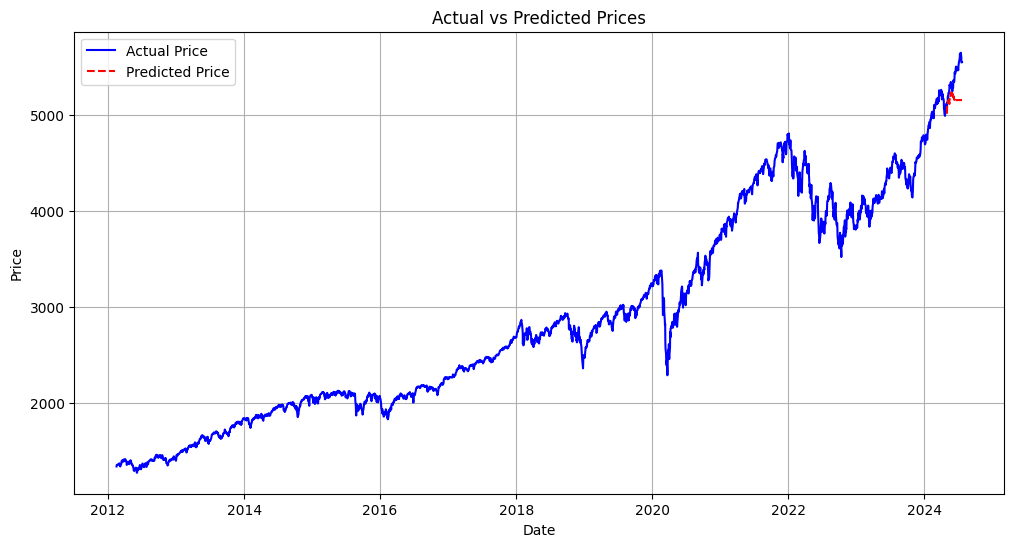

In [21]:
def plot_predictions_test(exchange):
    
    df_reality, df_pred = return_test_prediction_data(exchange)
    
    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(df_reality['datetime'], df_reality['Open'], label='Actual Price', color='blue')
    plt.plot(df_pred['datetime'], df_pred['Open'], label='Predicted Price', color='red', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.title('Actual vs Predicted Prices')
    plt.legend()
    plt.grid(True)
    plt.show()
    

exchange = '^GSPC'   
plot_predictions_test(exchange)


In [19]:
exchange = 'BTC-USD'
model = charge_model(exchange)

train_test, pred = return_test_prediction_data(exchange)

Model loaded successfully.
MySQL DB Connected


100%|██████████| 1/1 [00:02<00:00,  2.37s/it]


Model loaded successfully.
There is a model registered
MySQL DB Connected
MySQL DB Connected


100%|██████████| 1/1 [00:02<00:00,  2.23s/it]


In [6]:
def predict_exchange_future(exchange, days):

    df_original = get_daily_data(exchange)

    df = df_original[['id_date', 'Open','Exchange']]
    df['datetime'] = pd.to_datetime(df['id_date'], format='%Y%m%d')
    df = df[['datetime', 'Open', 'Exchange']]

    features, targets = transform_ts_data_into_features_and_target(
        df,
        input_seq_len=31, # one week of history -> 24*7*1
        step_size=1,
    )

    past_close_columns = [c for c in features.columns if c.startswith('open_')]

    features_only_numeric = features[past_close_columns]
    dates = features[['datetime']]

    df = pd.DataFrame()
    df_dates = pd.DataFrame()

    last_day = features_only_numeric.iloc[-1:]
    last_date = dates.iloc[-1:]

    model = charge_model(exchange)

    prediction = model.predict(last_day)

    df = pd.concat([df, last_day], ignore_index = True)
    df['predicted_price'] = prediction

    #dates
    last_date_day = last_date.iloc[-1]
    df_dates = pd.concat([df_dates, last_date], ignore_index = True)
    day = last_date_day

    for i in range(1,days):

        last_row = df.iloc[-1]
        last_row = last_row.drop('predicted_price')
        
        new_row = last_row.shift(-1)
        new_row['open_previous_1_day'] = prediction
        new_row_df = pd.DataFrame([new_row], columns=df.columns)
        
        prediction = model.predict(new_row_df)
        new_row_df['predicted_price'] = prediction

        df = pd.concat([df, new_row_df], ignore_index = True)
        
        #dates
        day = day + timedelta(days = 1)
        new_row_date = pd.DataFrame([day], columns = df_dates.columns)
        df_dates = pd.concat([df_dates, new_row_date], ignore_index = True)
        
    result = pd.concat([df, df_dates], axis=1)
    result['exchange'] = exchange
    
    return result


MySQL DB Connected


100%|██████████| 1/1 [00:02<00:00,  2.44s/it]


Model loaded successfully.
MySQL DB Connected


100%|██████████| 1/1 [00:01<00:00,  1.82s/it]


Model loaded successfully.
There is a model registered
MySQL DB Connected
MySQL DB Connected


100%|██████████| 1/1 [00:01<00:00,  1.76s/it]


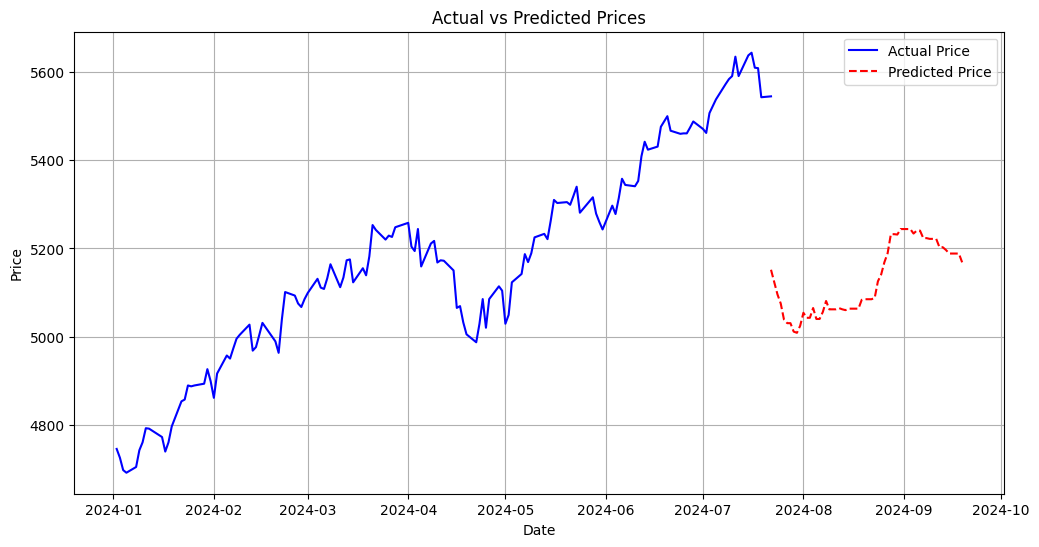

In [22]:
exchange = '^GSPC'
result = predict_exchange_future(exchange,60)

result = result[['datetime', 'predicted_price']]
result = result.rename(columns = {'predicted_price': 'Open'})
result['Exchange'] = exchange


df_reality, df_pred = return_test_prediction_data(exchange)


result
df_reality

df_reality = df_reality[df_reality['datetime'] > '2024-01-01']

    # Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_reality['datetime'], df_reality['Open'], label='Actual Price', color='blue')
plt.plot(result['datetime'], result['Open'], label='Predicted Price', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def return_prediction_data(exchange):
        
        X_test_only_numeric, X_train_only_numeric, y_test, y_train, X_train, X_test = ts_into_features_Daily(exchange)
        predictions = predict_exchange_future(exchange)

        #historical_data = 

        X_train = X_train[['datetime']]
        X_train['Open'] = y_train
        X_train['Exchange'] = exchange
        X_train

        X_test = X_test[['datetime']]
        X_test['Open'] = y_test
        X_test['Exchange'] = exchange
        X_test

        pred = X_test[['datetime']]
        pred['Open'] = predictions
        pred['Exchange'] = exchange


        train_test = pd.concat([X_train, X_test], ignore_index = True)
        
        return train_test, pred